# Multi-pair Hypersim vs DIODE — RQ1 insights

Plots the multi-pair RQ1 results from two new exports:

- `rq1_hypersym_100scenes_4000samplesnull.csv` — Hypersim, 100 scenes, $n{=}4000$ samples.
- `rq1_diode_train+val_indoor+outdoor_null.csv` — DIODE train+val (indoor+outdoor), $n{=}1169$ or $3395$ per pair.

Both CSVs share the same schema and **do not carry null-distribution columns** — only raw similarity values. Plots below therefore show absolute similarity per layer; significance testing on these runs is on the milestone-2 list.

Pairs fall into three categories:
- **Cross-modality (3):** `rgb-depth`, `depth-normals`, `rgb-normals` — the question RQ1 was designed for.
- **Self-vs-joint (6):** e.g. `rgb-rgb_joint_with_depth` compares a modality fed alone vs that modality fed jointly with a partner. Probes whether adding a second modality shifts the first's representation.
- **Joint-vs-joint (3):** both sides are joint inputs (e.g. `rgb_joint_with_depth-depth_joint_with_rgb`). Briefly inspected at the end.

**Outputs (saved to `../figures/`):**
- `multipair_overview_hypersim.pdf`, `multipair_overview_diode.pdf` — per-dataset overview, cross-modality.
- `multipair_hypersim_vs_diode.pdf` — 3×3 grid, datasets overlaid.
- `multipair_peak_summary.pdf` — peak similarity bars per pair × metric × dataset.
- `multipair_joint_conditioning.pdf` — self-vs-joint pairs.

In [1]:
%config InlineBackend.figure_format = "retina"

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

CSV_HYPERSIM = Path("rq1_hypersym_100scenes_4000samplesnull.csv")
CSV_DIODE = Path("rq1_diode_train+val_indoor+outdoor_null.csv")
OUT_DIR = Path("../figures")
OUT_DIR.mkdir(parents=True, exist_ok=True)

METRIC_ORDER = ["cka", "pwcca", "knn_overlap"]
METRIC_LABEL = {"cka": "CKA", "pwcca": "PWCCA", "knn_overlap": "k-NN overlap"}
METRIC_COLOR = {"cka": "#1f77b4", "pwcca": "#d62728", "knn_overlap": "#2ca02c"}

CROSS_PAIRS = ["rgb-depth", "depth-normals", "rgb-normals"]
JOINT_PAIRS = [
    "rgb-rgb_joint_with_depth",
    "rgb-rgb_joint_with_normals",
    "depth-depth_joint_with_rgb",
    "depth-depth_joint_with_normals",
    "normals-normals_joint_with_rgb",
    "normals-normals_joint_with_depth",
]
JOINT_CROSS_PAIRS = [
    "rgb_joint_with_depth-depth_joint_with_rgb",
    "rgb_joint_with_normals-normals_joint_with_rgb",
    "depth_joint_with_normals-normals_joint_with_depth",
]

PAIR_LABEL = {
    "rgb-depth": "RGB \u2194 Depth",
    "depth-normals": "Depth \u2194 Normals",
    "rgb-normals": "RGB \u2194 Normals",
    "rgb-rgb_joint_with_depth": "RGB | +Depth",
    "rgb-rgb_joint_with_normals": "RGB | +Normals",
    "depth-depth_joint_with_rgb": "Depth | +RGB",
    "depth-depth_joint_with_normals": "Depth | +Normals",
    "normals-normals_joint_with_rgb": "Normals | +RGB",
    "normals-normals_joint_with_depth": "Normals | +Depth",
    "rgb_joint_with_depth-depth_joint_with_rgb": "RGB|+D \u2194 Depth|+RGB",
    "rgb_joint_with_normals-normals_joint_with_rgb": "RGB|+N \u2194 Normals|+RGB",
    "depth_joint_with_normals-normals_joint_with_depth": "Depth|+N \u2194 Normals|+D",
}

PAIR_COLOR = {
    "rgb-depth": "#1f77b4",
    "depth-normals": "#9467bd",
    "rgb-normals": "#e87a22",
}
PAIR_MARKER = {"rgb-depth": "o", "depth-normals": "s", "rgb-normals": "^"}

DATASET_STYLE = {"Hypersim": "-", "DIODE": "--"}
DATASET_MARKER = {"Hypersim": "o", "DIODE": "s"}

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "pdf.fonttype": 42,
    "font.family": "serif",
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 9.5,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linewidth": 0.4,
    "lines.linewidth": 1.4,
})

In [2]:
def load(path: Path, dataset: str) -> pd.DataFrame:
    d = pd.read_csv(path)
    d["dataset"] = dataset
    d["layer_idx"] = d["layer"].str.extract(r"layer_(\d+)").astype(int)
    return d

df = pd.concat([
    load(CSV_HYPERSIM, "Hypersim"),
    load(CSV_DIODE, "DIODE"),
], ignore_index=True)
df = df.sort_values(["dataset", "pair", "metric", "layer_idx"]).reset_index(drop=True)
df[["dataset", "pair", "metric", "layer_idx", "value", "n_samples"]].head()

,dataset,pair,metric,layer_idx,value,n_samples
0,DIODE,depth-depth_joint_with_normals,cka,0,0.999413,1169
1,DIODE,depth-depth_joint_with_normals,cka,1,0.995771,1169
2,DIODE,depth-depth_joint_with_normals,cka,2,0.996027,1169
3,DIODE,depth-depth_joint_with_normals,cka,3,0.988063,1169
4,DIODE,depth-depth_joint_with_normals,cka,4,0.985699,1169


## Section A — Per-dataset overview (cross-modality)

One figure per dataset. Three panels (one per metric), three cross-modality pair lines overlaid.

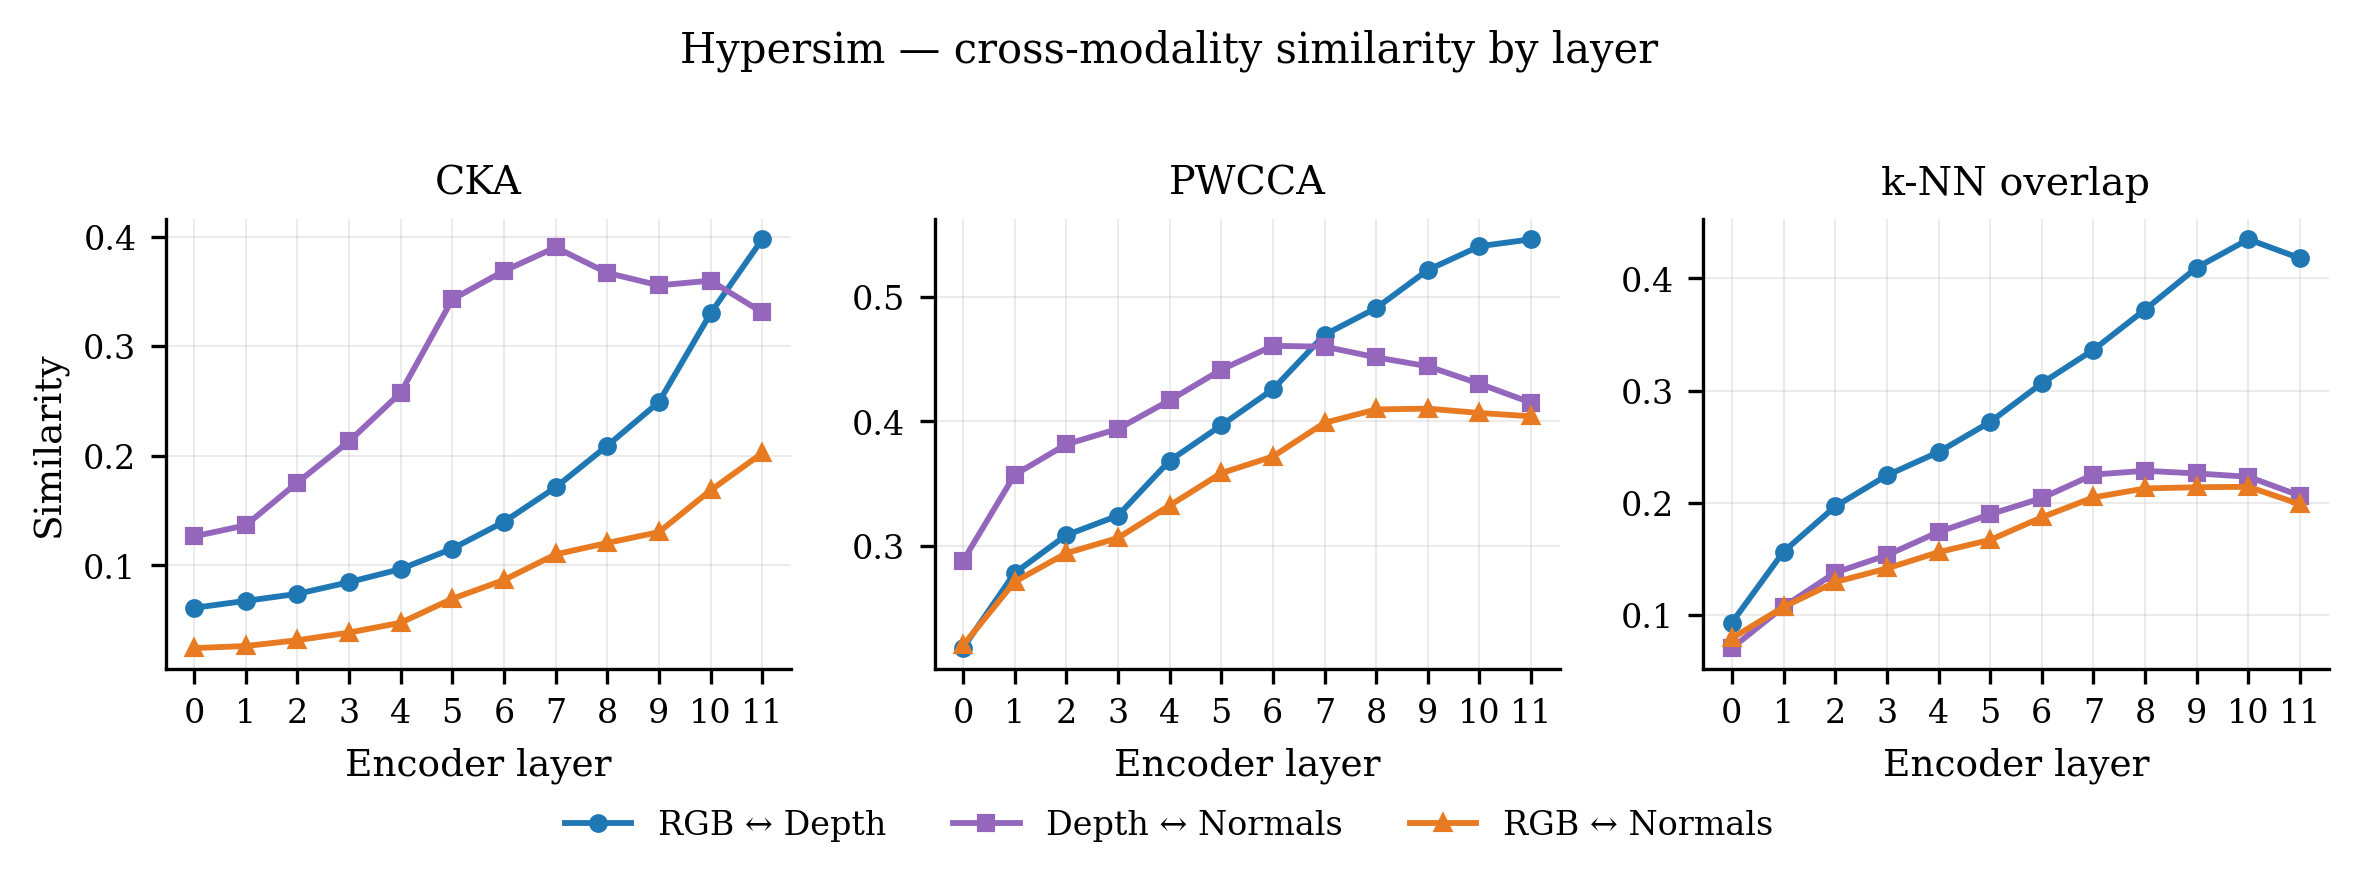

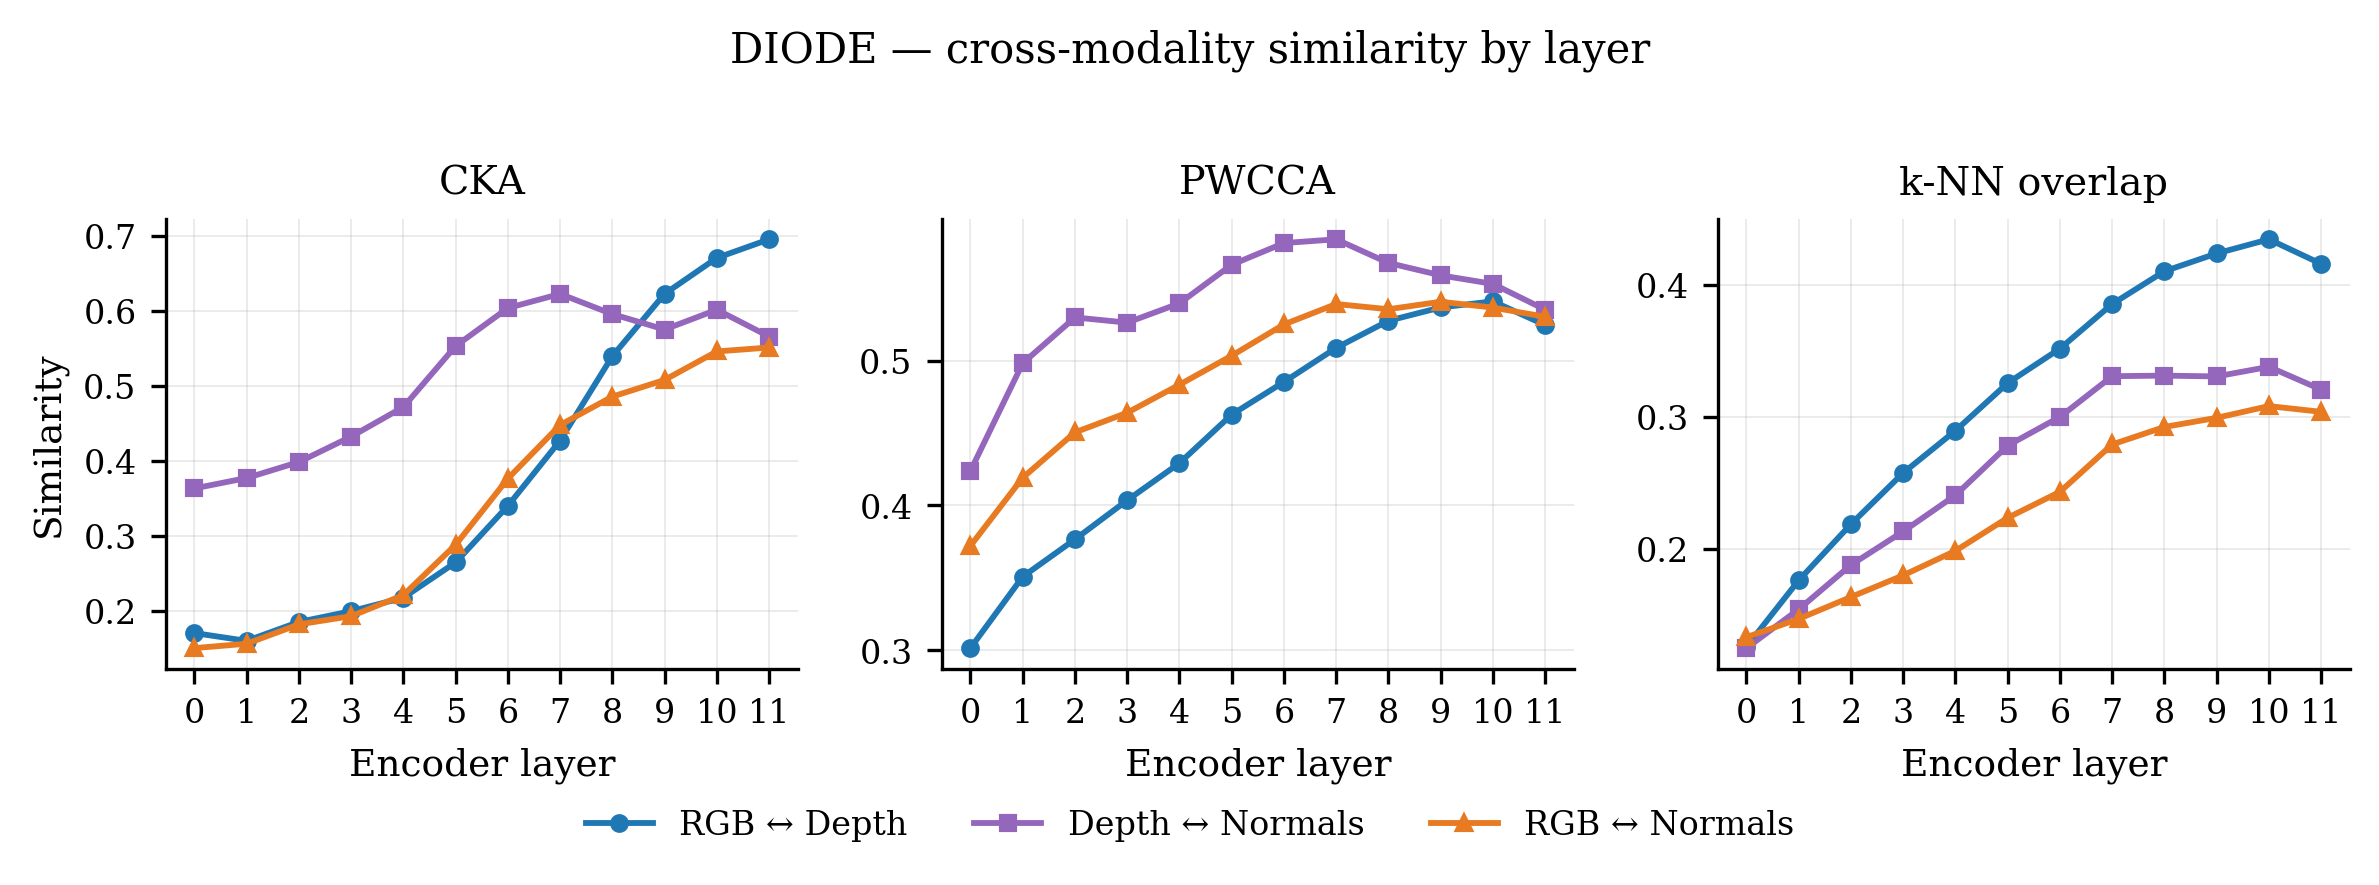

In [3]:
def plot_overview(dataset_name: str, out_name: str) -> None:
    sub_df = df[(df["dataset"] == dataset_name) & (df["pair"].isin(CROSS_PAIRS))]

    fig, axes = plt.subplots(1, 3, figsize=(8.0, 2.6), sharex=True)
    for ax, metric in zip(axes, METRIC_ORDER):
        for pair in CROSS_PAIRS:
            curve = sub_df[(sub_df["metric"] == metric) & (sub_df["pair"] == pair)].sort_values("layer_idx")
            ax.plot(
                curve["layer_idx"], curve["value"],
                marker=PAIR_MARKER[pair], markersize=3.5,
                color=PAIR_COLOR[pair], label=PAIR_LABEL[pair],
            )
        ax.set_title(METRIC_LABEL[metric])
        ax.set_xlabel("Encoder layer")
        ax.set_xticks(range(0, 12))

    axes[0].set_ylabel("Similarity")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False,
               bbox_to_anchor=(0.5, -0.06))
    fig.suptitle(f"{dataset_name} — cross-modality similarity by layer", y=1.02, fontsize=10)
    fig.tight_layout()
    fig.savefig(OUT_DIR / out_name)
    plt.show()


plot_overview("Hypersim", "multipair_overview_hypersim.pdf")
plot_overview("DIODE", "multipair_overview_diode.pdf")

## Section B — Hypersim vs DIODE (cross-modality)

### B1. Grid: metric × pair, dataset as line style

$3 \times 3$ grid (rows = metric, cols = pair). In each panel, **solid = Hypersim, dashed = DIODE**. Direct read of where the two datasets agree and where they diverge.

*Note:* DIODE's `n_samples` varies per pair (1169 or 3395) while Hypersim is constant at 4000 — relevant when interpreting layer-to-layer variance.

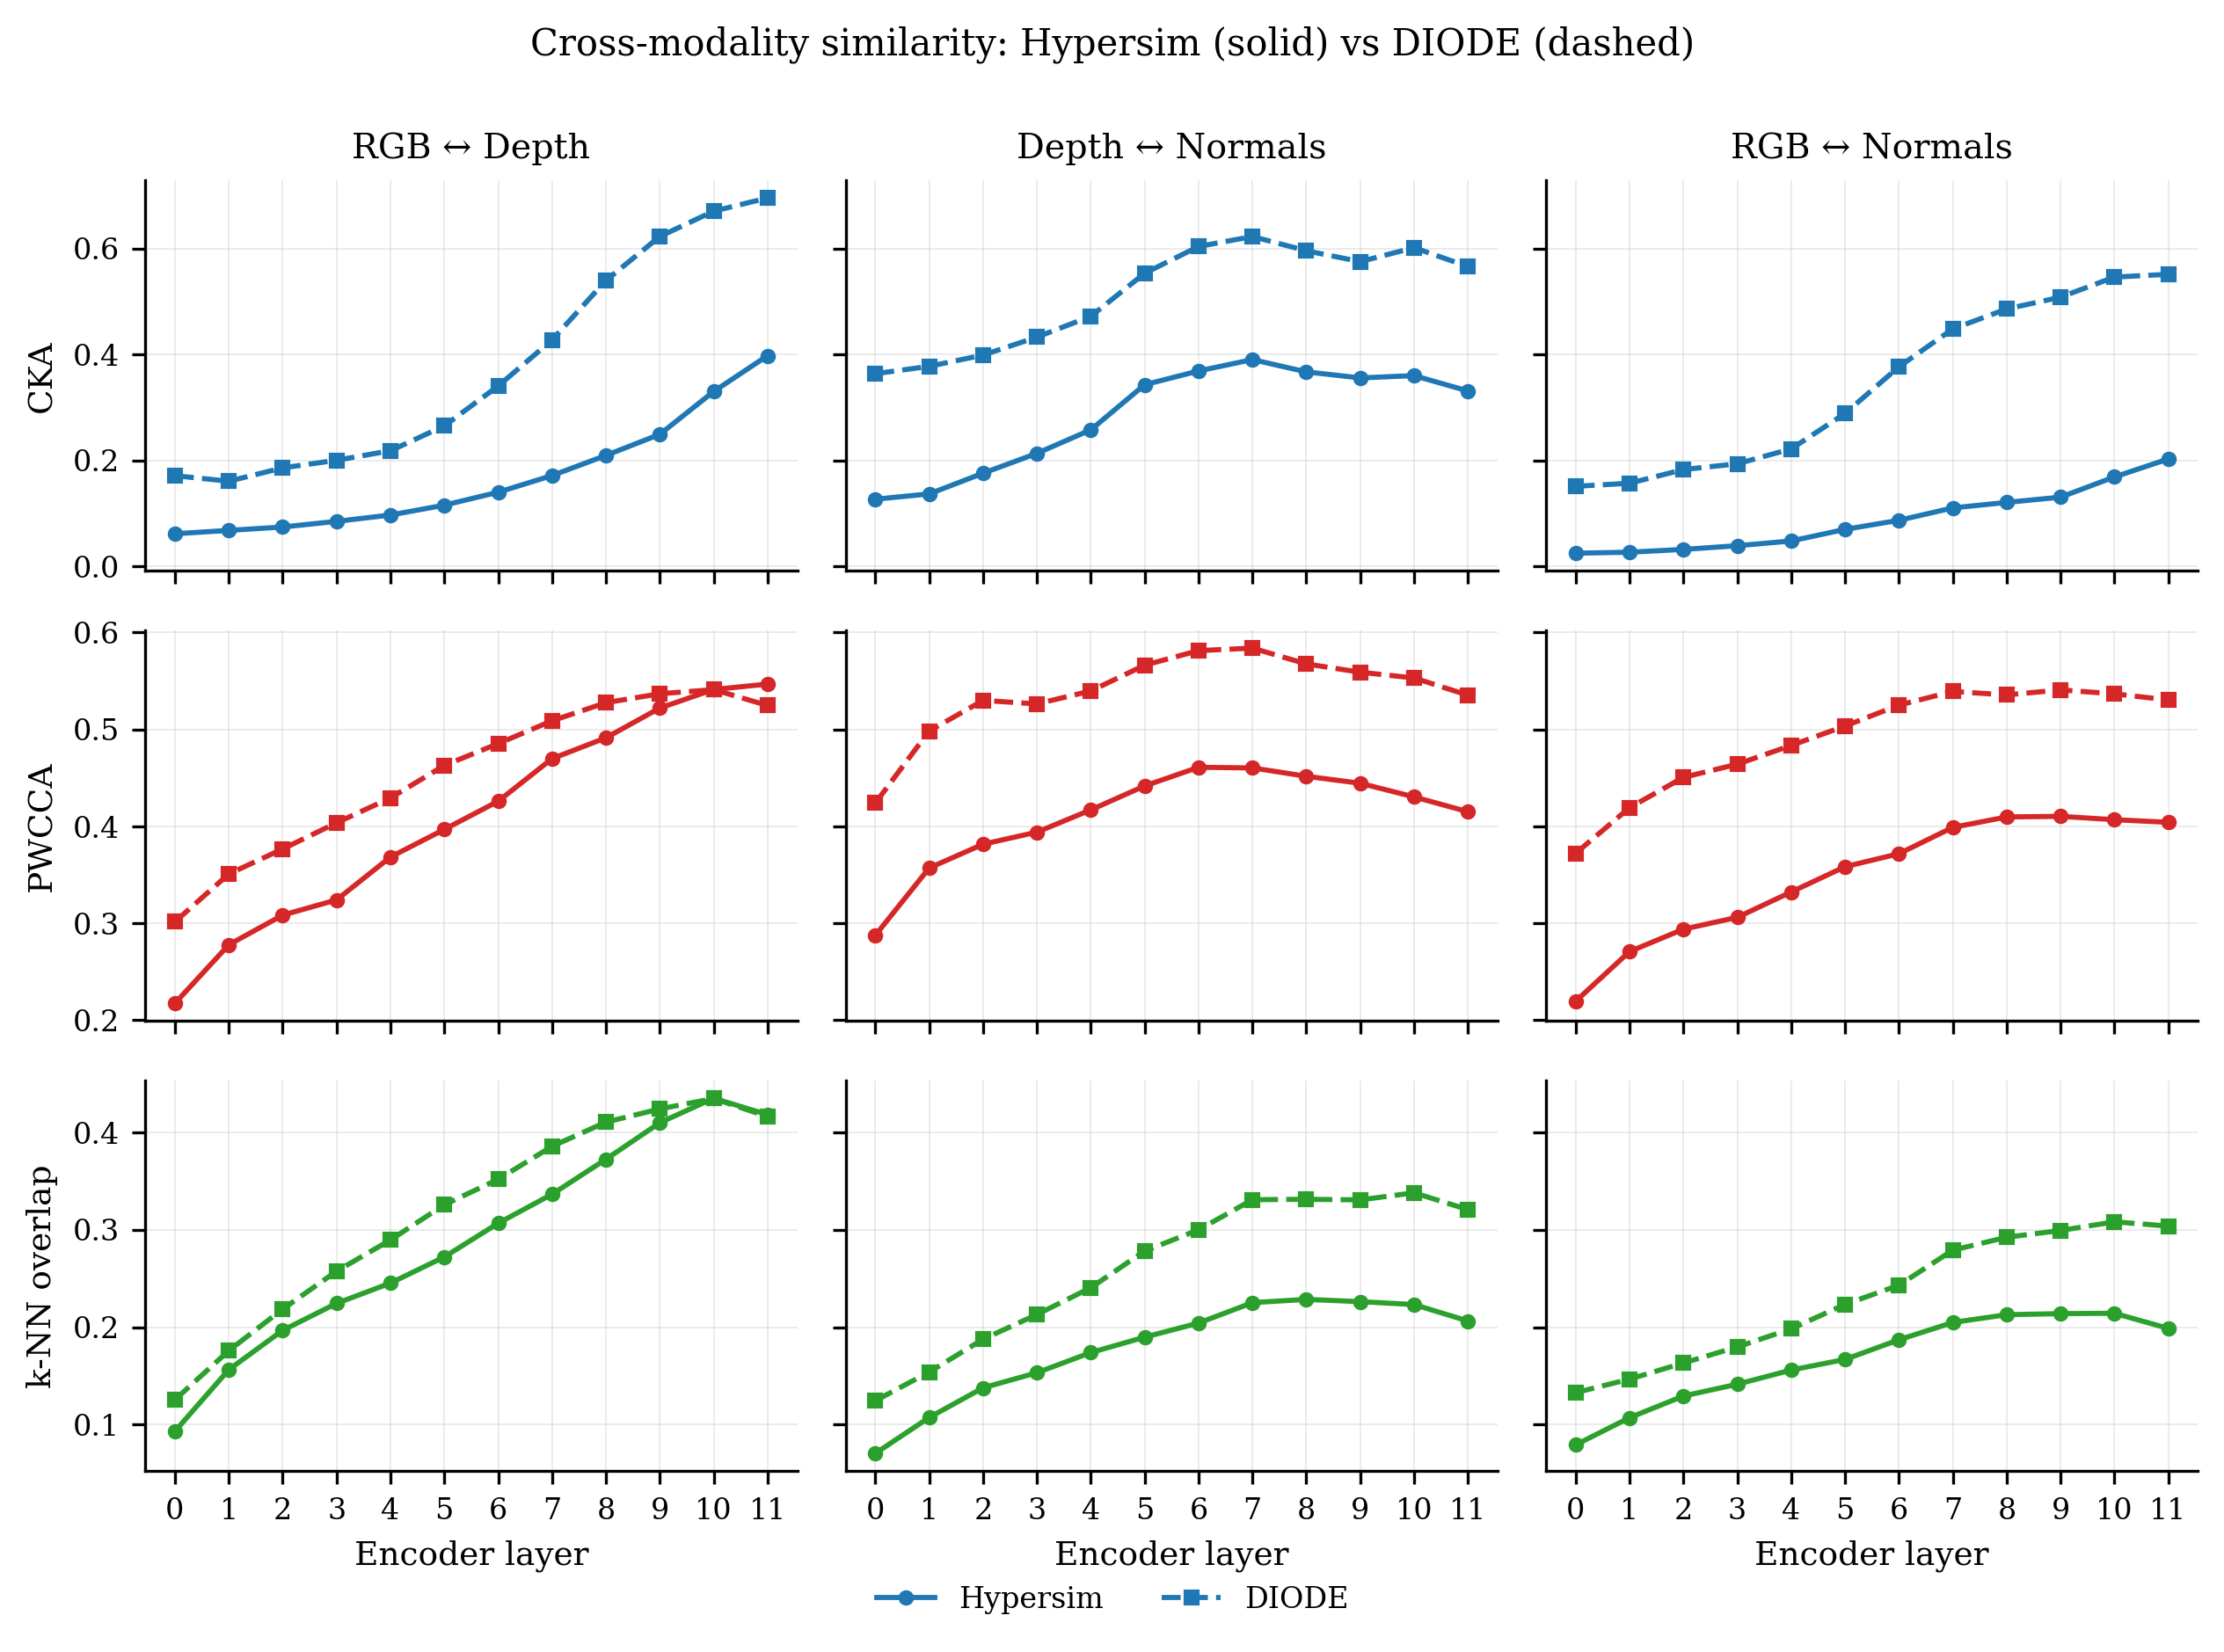

In [4]:
fig, axes = plt.subplots(
    len(METRIC_ORDER), len(CROSS_PAIRS),
    figsize=(8.5, 6.0),
    sharex=True, sharey="row",
)

for i, metric in enumerate(METRIC_ORDER):
    for j, pair in enumerate(CROSS_PAIRS):
        ax = axes[i, j]
        for dataset, style in DATASET_STYLE.items():
            curve = df[(df["dataset"] == dataset)
                       & (df["metric"] == metric)
                       & (df["pair"] == pair)].sort_values("layer_idx")
            ax.plot(
                curve["layer_idx"], curve["value"],
                linestyle=style, marker=DATASET_MARKER[dataset], markersize=3.2,
                color=METRIC_COLOR[metric], label=dataset,
            )
        if i == 0:
            ax.set_title(PAIR_LABEL[pair])
        if j == 0:
            ax.set_ylabel(METRIC_LABEL[metric])
        if i == len(METRIC_ORDER) - 1:
            ax.set_xlabel("Encoder layer")
        ax.set_xticks(range(0, 12))

# single legend, top-right of the grid
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False,
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Cross-modality similarity: Hypersim (solid) vs DIODE (dashed)",
             y=1.0, fontsize=10)
fig.tight_layout()
fig.savefig(OUT_DIR / "multipair_hypersim_vs_diode.pdf")
plt.show()

### B2. Peak similarity summary

Per-`(metric, pair)` peak value across the 12 layers, split by dataset. Strips out layer detail to expose the pair ranking at a glance. Numbers above each bar = layer at which the peak occurs.

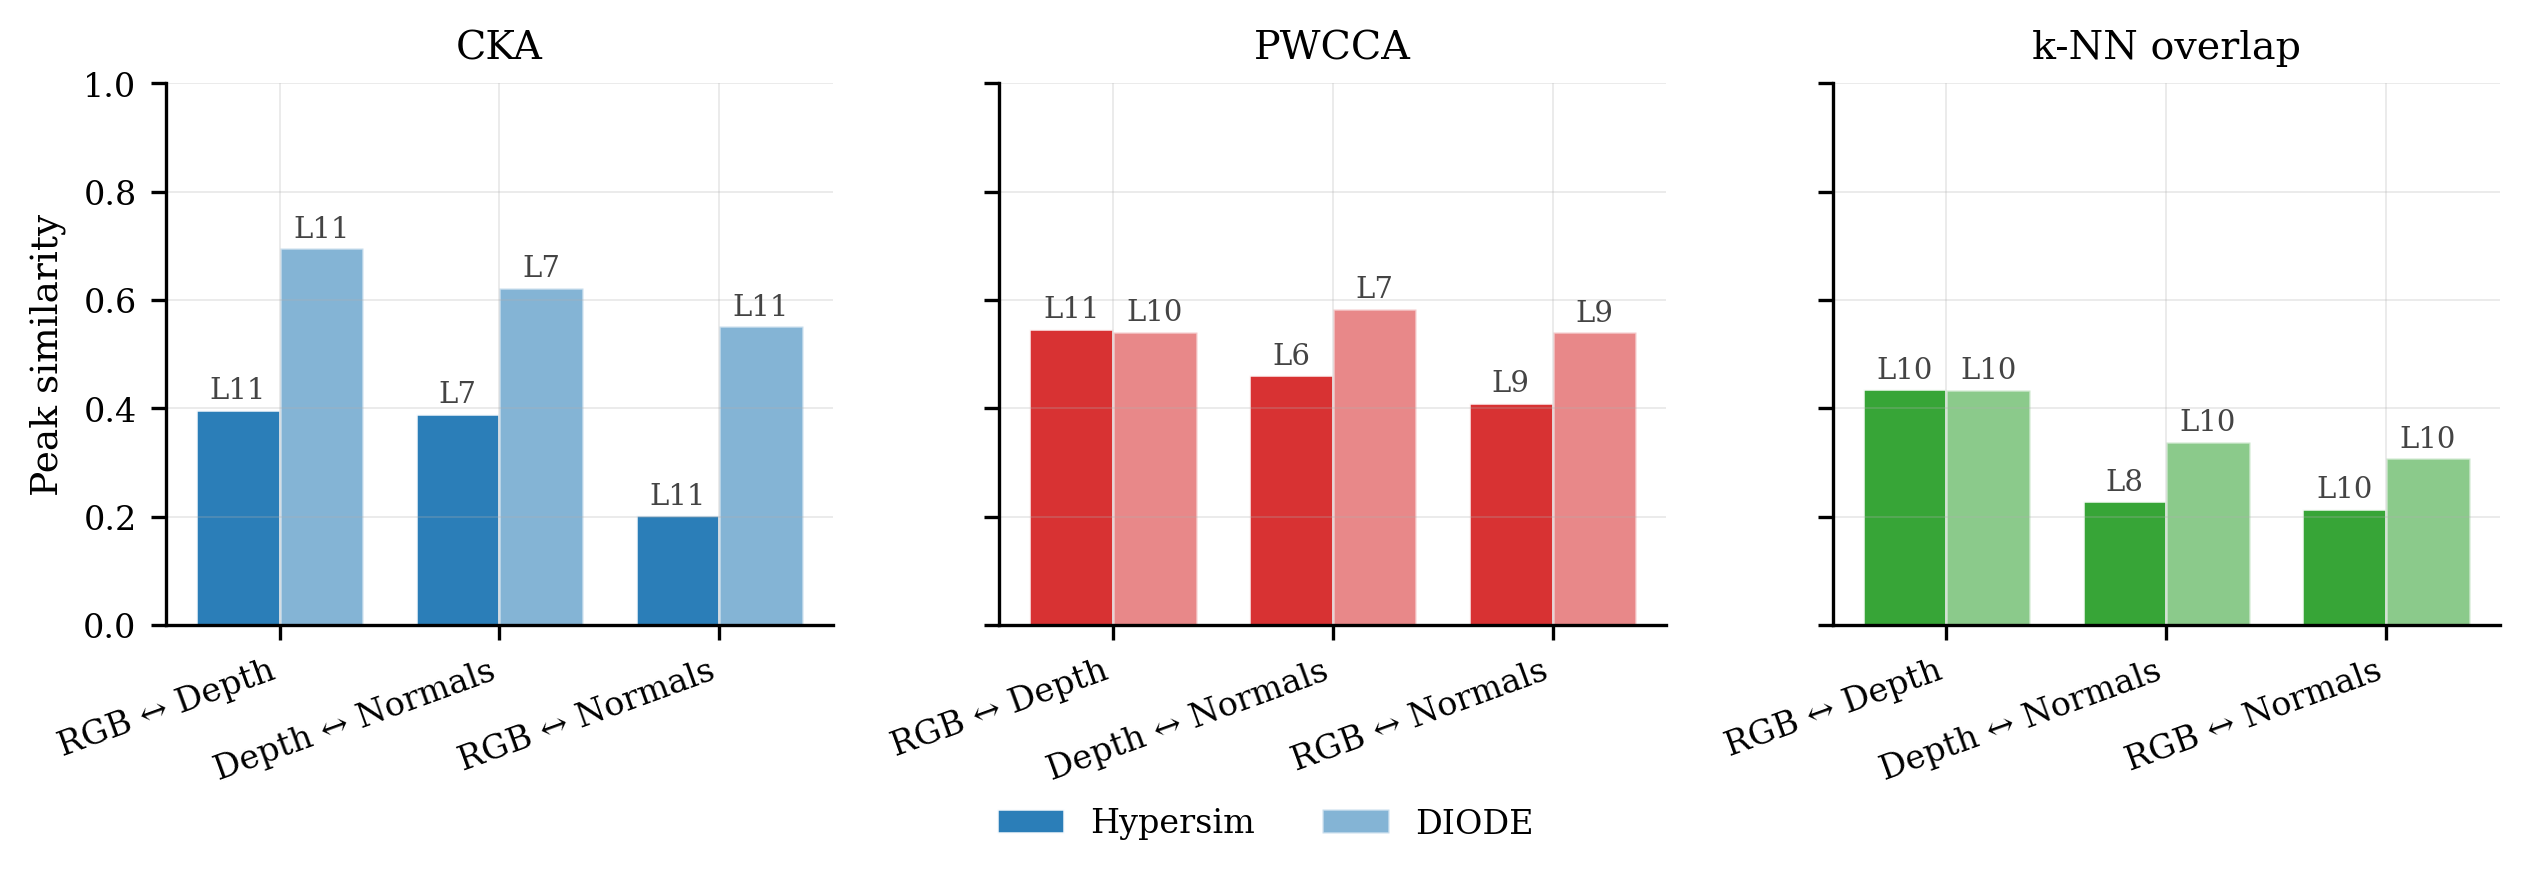

In [5]:
def peak_table(pairs: list[str]) -> pd.DataFrame:
    sub_df = df[df["pair"].isin(pairs)]
    idx = sub_df.groupby(["dataset", "pair", "metric"])["value"].idxmax()
    return sub_df.loc[idx, ["dataset", "pair", "metric", "layer_idx", "value"]].reset_index(drop=True)


peaks = peak_table(CROSS_PAIRS)

fig, axes = plt.subplots(1, len(METRIC_ORDER), figsize=(8.5, 2.8), sharey=True)
x = np.arange(len(CROSS_PAIRS))
width = 0.38

for ax, metric in zip(axes, METRIC_ORDER):
    for k, (dataset, hatch) in enumerate([("Hypersim", ""), ("DIODE", "//")]):
        vals = [peaks[(peaks["metric"] == metric)
                      & (peaks["pair"] == p)
                      & (peaks["dataset"] == dataset)]["value"].iloc[0]
                for p in CROSS_PAIRS]
        layers = [peaks[(peaks["metric"] == metric)
                        & (peaks["pair"] == p)
                        & (peaks["dataset"] == dataset)]["layer_idx"].iloc[0]
                  for p in CROSS_PAIRS]
        bars = ax.bar(
            x + (k - 0.5) * width, vals, width,
            color=METRIC_COLOR[metric],
            alpha=0.95 if dataset == "Hypersim" else 0.55,
            edgecolor="white", linewidth=0.6,
            label=dataset,
        )
        for b, lay in zip(bars, layers):
            ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01,
                    f"L{lay}", ha="center", va="bottom", fontsize=7, color="#444")
    ax.set_xticks(x)
    ax.set_xticklabels([PAIR_LABEL[p] for p in CROSS_PAIRS], rotation=20, ha="right")
    ax.set_title(METRIC_LABEL[metric])
    ax.set_ylim(0, 1.0)

axes[0].set_ylabel("Peak similarity")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False,
           bbox_to_anchor=(0.5, -0.05))
fig.tight_layout()
fig.savefig(OUT_DIR / "multipair_peak_summary.pdf")
plt.show()

## Section C — Self-vs-joint conditioning effect

Pairs of the form `X-X_joint_with_Y` compare a modality fed **alone** with that same modality fed **jointly with a partner Y**.

- Values close to **1** ⇒ the encoder largely **ignored the partner**; the modality's representation is unchanged.
- Values **< 1** ⇒ the partner **shifted** the representation; the encoder integrated information from both inputs.

Grid: rows = metric, cols = the six self-vs-joint pairs. Solid = Hypersim, dashed = DIODE.

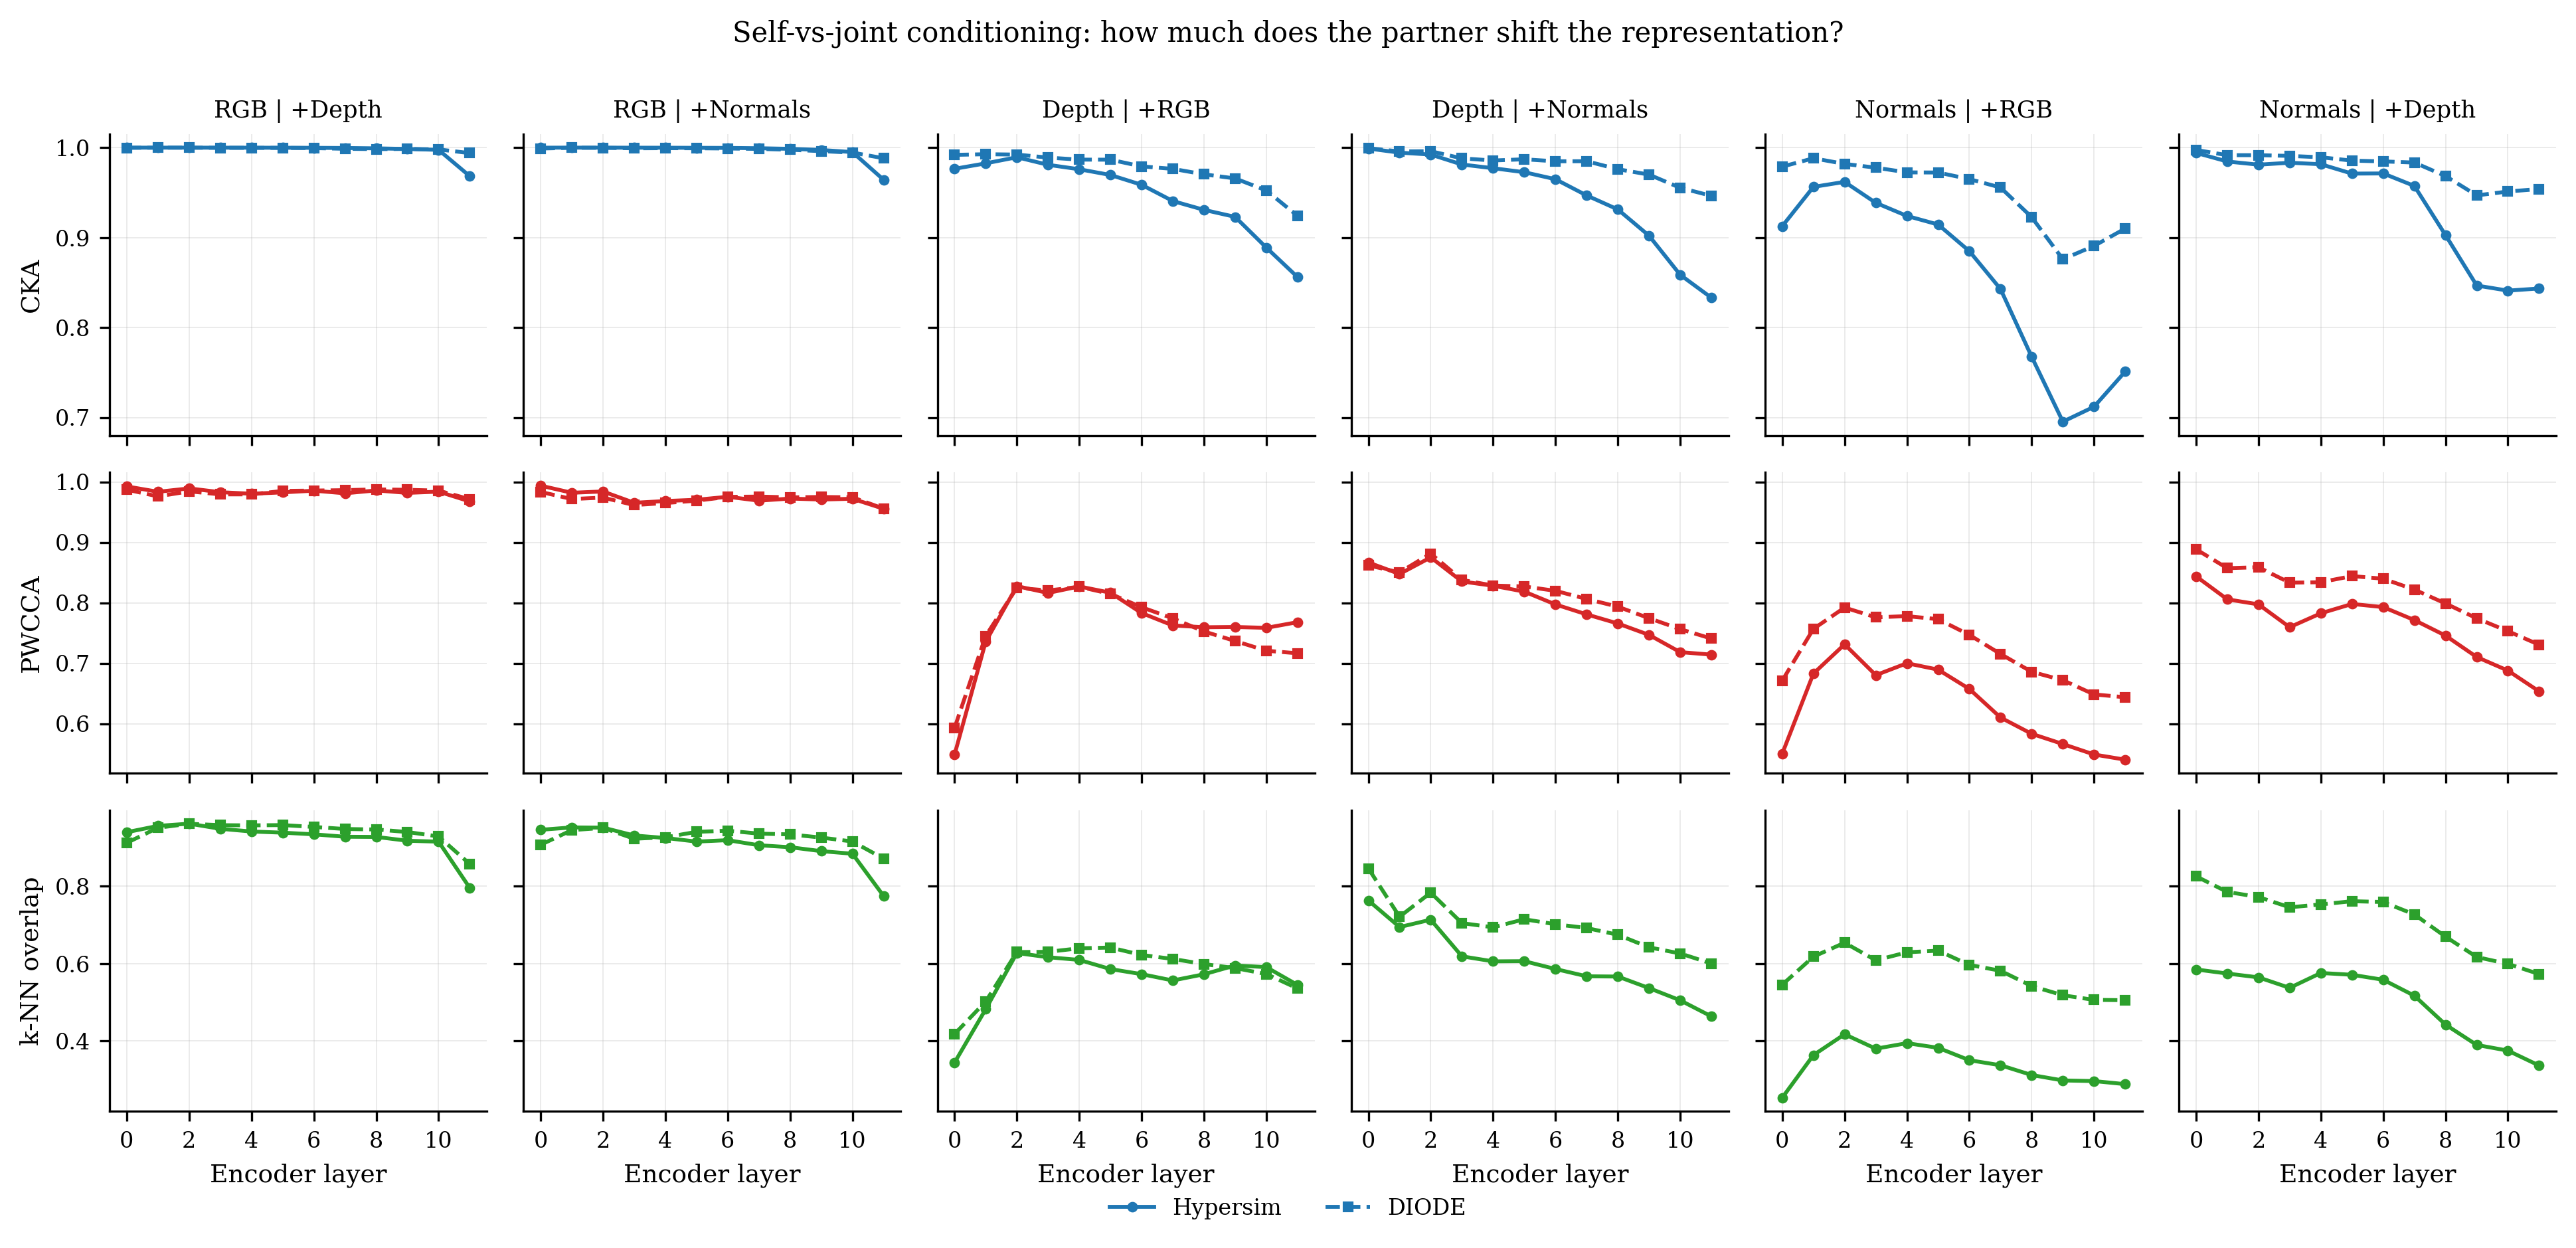

In [6]:
fig, axes = plt.subplots(
    len(METRIC_ORDER), len(JOINT_PAIRS),
    figsize=(13.0, 6.0),
    sharex=True, sharey="row",
)

for i, metric in enumerate(METRIC_ORDER):
    for j, pair in enumerate(JOINT_PAIRS):
        ax = axes[i, j]
        for dataset, style in DATASET_STYLE.items():
            curve = df[(df["dataset"] == dataset)
                       & (df["metric"] == metric)
                       & (df["pair"] == pair)].sort_values("layer_idx")
            ax.plot(
                curve["layer_idx"], curve["value"],
                linestyle=style, marker=DATASET_MARKER[dataset], markersize=2.8,
                color=METRIC_COLOR[metric], label=dataset,
            )
        if i == 0:
            ax.set_title(PAIR_LABEL[pair], fontsize=8.5)
        if j == 0:
            ax.set_ylabel(METRIC_LABEL[metric])
        if i == len(METRIC_ORDER) - 1:
            ax.set_xlabel("Encoder layer")
        ax.set_xticks(range(0, 12, 2))

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False,
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Self-vs-joint conditioning: how much does the partner shift the representation?",
             y=1.0, fontsize=10)
fig.tight_layout()
fig.savefig(OUT_DIR / "multipair_joint_conditioning.pdf")
plt.show()

## Section D — Numerical summary

### D1. Peak similarity per (dataset, pair, metric)

In [7]:
all_peaks = peak_table(CROSS_PAIRS + JOINT_PAIRS + JOINT_CROSS_PAIRS)

pivot_value = all_peaks.pivot(index=["pair"], columns=["dataset", "metric"], values="value").round(3)
pivot_value

dataset                                            DIODE                     \
metric                                               cka knn_overlap  pwcca   
pair                                                                          
depth-depth_joint_with_normals                     0.999       0.846  0.881   
depth-depth_joint_with_rgb                         0.993       0.641  0.826   
depth-normals                                      0.622       0.338  0.584   
depth_joint_with_normals-normals_joint_with_depth  0.699       0.511  0.806   
normals-normals_joint_with_depth                   0.997       0.825  0.888   
normals-normals_joint_with_rgb                     0.988       0.654  0.792   
rgb-depth                                          0.695       0.434  0.541   
rgb-normals                                        0.551       0.308  0.541   
rgb-rgb_joint_with_depth                           1.000       0.961  0.988   
rgb-rgb_joint_with_normals                         1.000       0.950  0.983   
rgb_joint_with_depth-depth_joint_with_rgb          0.783       0.603  0.759   
rgb_joint_with_normals-normals_joint_with_rgb      0.713       0.511  0.817   

dataset                                           Hypersim                     
metric                                                 cka knn_overlap  pwcca  
pair                                                                           
depth-depth_joint_with_normals                       0.999       0.763  0.875  
depth-depth_joint_with_rgb                           0.989       0.627  0.828  
depth-normals                                        0.390       0.228  0.461  
depth_joint_with_normals-normals_joint_with_depth    0.615       0.414  0.782  
normals-normals_joint_with_depth                     0.994       0.585  0.844  
normals-normals_joint_with_rgb                       0.962       0.417  0.731  
rgb-depth                                            0.398       0.435  0.547  
rgb-normals                                          0.203       0.214  0.410  
rgb-rgb_joint_with_depth                             1.000       0.961  0.993  
rgb-rgb_joint_with_normals                           1.000       0.952  0.994  
rgb_joint_with_depth-depth_joint_with_rgb            0.518       0.578  0.763  
rgb_joint_with_normals-normals_joint_with_rgb        0.508       0.523  0.788

In [ ]:
pivot_layer = all_peaks.pivot(index=["pair"], columns=["dataset", "metric"], values="layer_idx")
pivot_layer

### D2. Dataset gap at the peak layer

DIODE − Hypersim per `(pair, metric)`, evaluated at each dataset's own peak layer. Positive ⇒ DIODE shows stronger convergence at its peak; negative ⇒ Hypersim does.

In [8]:
h_peaks = all_peaks[all_peaks["dataset"] == "Hypersim"].set_index(["pair", "metric"])["value"]
d_peaks = all_peaks[all_peaks["dataset"] == "DIODE"].set_index(["pair", "metric"])["value"]
gap = (d_peaks - h_peaks).rename("DIODE_minus_Hypersim")
gap.unstack("metric").round(3)

metric,cka,knn_overlap,pwcca
pair,,,
depth-depth_joint_with_normals,0.000,0.083,0.006
depth-depth_joint_with_rgb,0.003,0.014,-0.001
depth-normals,0.232,0.109,0.123
depth_joint_with_normals-normals_joint_with_depth,0.084,0.097,0.024
normals-normals_joint_with_depth,0.003,0.241,0.045
normals-normals_joint_with_rgb,0.026,0.237,0.061
rgb-depth,0.298,-0.000,-0.006
rgb-normals,0.349,0.094,0.130
rgb-rgb_joint_with_depth,-0.000,-0.000,-0.005


### D3. Joint-vs-joint pairs

Three pairs in this category — both sides of the comparison were fed jointly. Reported here for completeness; interpretation is more involved than the cross-modality view.

In [9]:
joint_cross_peaks = peak_table(JOINT_CROSS_PAIRS)
joint_cross_peaks.pivot(index="pair", columns=["dataset", "metric"], values="value").round(3)

dataset                                            DIODE                     \
metric                                               cka knn_overlap  pwcca   
pair                                                                          
depth_joint_with_normals-normals_joint_with_depth  0.699       0.511  0.806   
rgb_joint_with_depth-depth_joint_with_rgb          0.783       0.603  0.759   
rgb_joint_with_normals-normals_joint_with_rgb      0.713       0.511  0.817   

dataset                                           Hypersim                     
metric                                                 cka knn_overlap  pwcca  
pair                                                                           
depth_joint_with_normals-normals_joint_with_depth    0.615       0.414  0.782  
rgb_joint_with_depth-depth_joint_with_rgb            0.518       0.578  0.763  
rgb_joint_with_normals-normals_joint_with_rgb        0.508       0.523  0.788